In [1]:
# ============================================
# Install Required Libraries
# ============================================

!pip install -q kaggle

In [2]:
# ============================================
# Import Libraries
# ============================================

import os
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

print("TensorFlow Version :", tf.__version__)
print("GPU Available :", tf.config.list_physical_devices('GPU'))

TensorFlow Version : 2.20.0
GPU Available : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
import os

os.environ["KAGGLE_USERNAME"] = "yogendratiwari12"
os.environ["KAGGLE_KEY"] = "KGAT_d7b2c048f60d5a2a8307a91cf67c09e2"

In [5]:
!kaggle datasets list -s "plant disease"

ref                                                         title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  --------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
vipoooool/new-plant-diseases-dataset                        New Plant Diseases Dataset                     2897709187  2018-11-18 07:09:16.050000         195011       1724  0.75             
sadmansakibmahi/plant-disease-expert                        Plant Disease Expert                          10019383772  2024-08-31 11:09:18.720000           8185        128  0.7058824        
turakut/plant-disease-classification                        Plant Disease Classification                       358274  2025-06-22 07:54:27.970000           2977         47  1                
rashikrahmanpritom/plant-disease-recognition-

In [10]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
Resuming from 412090368 bytes (2485618819 bytes left)...
100% 2.70G/2.70G [01:53<00:00, 21.8MB/s]



In [11]:
import zipfile

with zipfile.ZipFile("new-plant-diseases-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("✅ Dataset Extracted")

✅ Dataset Extracted


In [13]:
import os

os.listdir("dataset")

['new plant diseases dataset(augmented)',
 'test',
 'New Plant Diseases Dataset(Augmented)']

In [14]:
for root, dirs, files in os.walk("dataset"):
    print(root)
    if len(root.split(os.sep)) > 3:
        break

dataset
dataset/new plant diseases dataset(augmented)
dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)
dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train


In [15]:
import os

BASE_DIR = "dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"

train_dir = os.path.join(BASE_DIR, "train")
valid_dir = os.path.join(BASE_DIR, "valid")
test_dir = os.path.join(BASE_DIR, "test")

print(train_dir)
print(valid_dir)
print(test_dir)

dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid
dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/test


In [16]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 70295 files belonging to 38 classes.


In [17]:
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 17572 files belonging to 38 classes.


In [18]:
class_names = train_dataset.class_names

print("Total Classes:", len(class_names))
print(class_names)

Total Classes: 38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

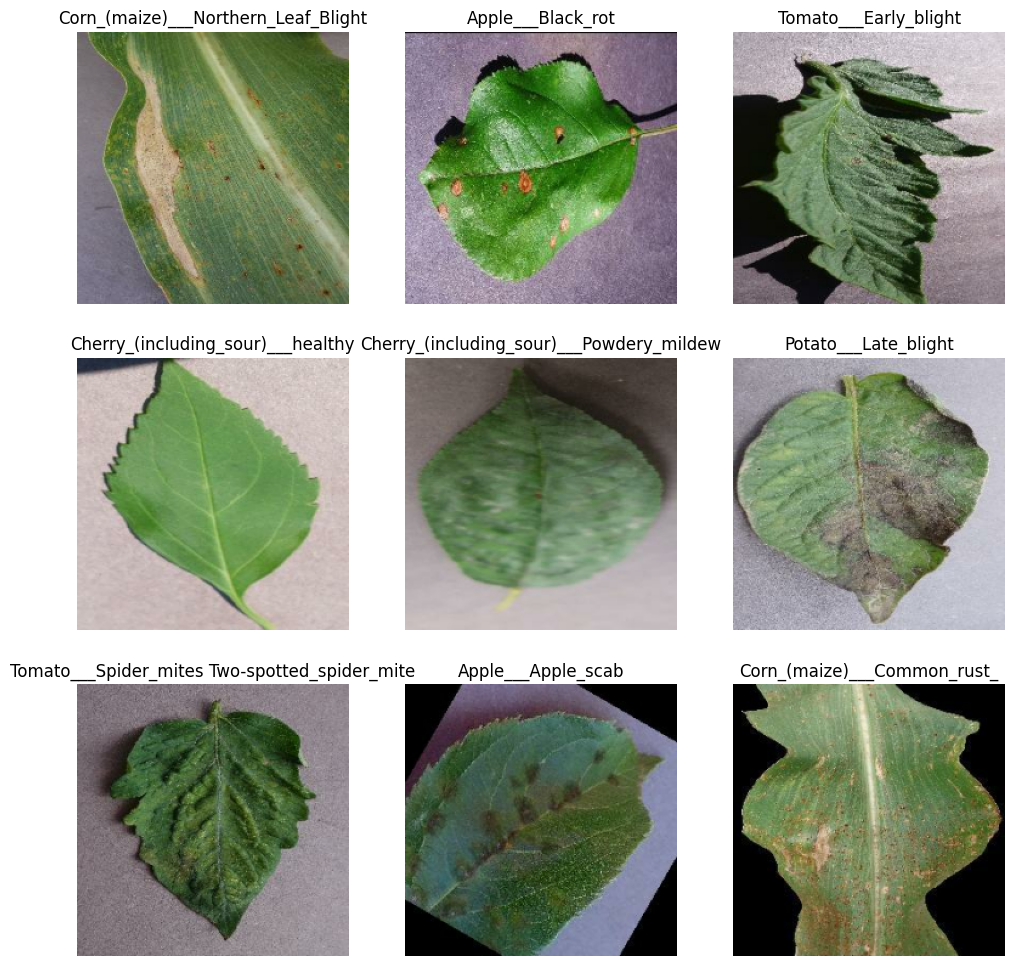

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [20]:
for image_batch, label_batch in train_dataset.take(1):

    print("Image Batch Shape :", image_batch.shape)

    print("Label Batch Shape :", label_batch.shape)

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32,)


In [21]:
print(image_batch[0])

tf.Tensor(
[[[188.53061  176.53061  176.53061 ]
  [179.86224  167.86224  167.86224 ]
  [174.46938  162.46938  162.46938 ]
  ...
  [184.31119  172.31119  172.31119 ]
  [183.94388  171.94388  171.94388 ]
  [187.79088  175.79088  175.79088 ]]

 [[185.25     173.25     173.25    ]
  [184.4643   172.4643   172.4643  ]
  [182.57144  170.57144  170.57144 ]
  ...
  [186.64792  174.64792  174.64792 ]
  [184.97449  172.97449  172.97449 ]
  [187.71434  175.71434  175.71434 ]]

 [[172.64287  160.64287  160.64287 ]
  [178.14287  166.14287  166.14287 ]
  [180.57144  168.57144  168.57144 ]
  ...
  [182.84178  170.84178  170.84178 ]
  [179.86223  167.86223  167.86223 ]
  [182.3572   170.3572   170.3572  ]]

 ...

 [[ 12.357132  15.357132  24.357132]
  [ 12.357132  15.357132  24.357132]
  [ 12.357132  15.357132  24.357132]
  ...
  [192.80618  186.80618  198.80618 ]
  [197.98454  191.98454  203.98454 ]
  [198.47966  192.47966  204.47966 ]]

 [[ 11.214279  14.214279  23.21428 ]
  [ 11.214279  14.214279  

In [22]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

valid_dataset = valid_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

print("✅ Images Normalized")

✅ Images Normalized


In [23]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        38,
        activation="softmax"
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,254,438 (84.89 MB)

 Trainable params: 22,254,438 (84.89 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [26]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_plant_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [27]:
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 159s 69ms/step - accuracy: 0.6021 - loss: 1.3529 - val_accuracy: 0.8349 - val_loss: 0.5326
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.8207 - loss: 0.5715 - val_accuracy: 0.9059 - val_loss: 0.2985
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 140s 63ms/step - accuracy: 0.8719 - loss: 0.4041 - val_accuracy: 0.9122 - val_loss: 0.2697
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 145s 65ms/step - accuracy: 0.8977 - loss: 0.3112 - val_accuracy: 0.9191 - val_loss: 0.2485
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 144s 65ms/step - accuracy: 0.9169 - loss: 0.2580 - val_accuracy: 0.9311 - val_loss: 0.2158
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9320 - loss: 0.2123 - val_accuracy: 0.9255 - val_loss: 0.2394
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 138s 63ms/step - accuracy: 0.9397 - loss: 0.1851 - val_accuracy: 0.9302 - val_loss: 0.2335
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 147s 67ms/step - accuracy: 

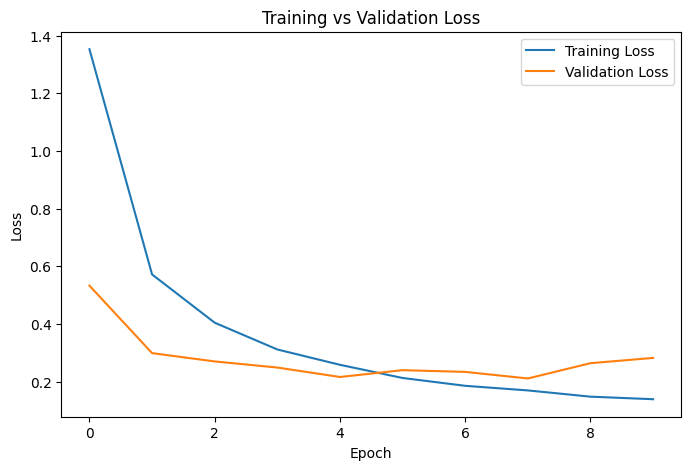

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [29]:
test_dir = os.path.join("dataset", "test")

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

Found 33 files belonging to 1 classes.


In [62]:
cnn_test_loss, cnn_test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy : {cnn_test_accuracy:.4f}")
print(f"Test Loss     : {cnn_test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0303 - loss: 29.2828
Test Accuracy : 0.0303
Test Loss     : 29.2828


In [31]:
model.save("plant_disease_cnn.keras")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [32]:
import random
import os
import matplotlib.pyplot as plt
import tensorflow as tf

In [33]:
BASE_DIR = "dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"
image_dir = os.path.join(BASE_DIR, "valid") # Changed from test_dir to valid_dir

random_class = random.choice(class_names)

random_image = random.choice(
    os.listdir(os.path.join(image_dir, random_class))
)

image_path = os.path.join(
    image_dir,
    random_class,
    random_image
)

print(image_path)

dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Peach___Bacterial_spot/d2a3a8be-f759-439f-a5d0-0c399e8340f6___Rutg._Bact.S 2231.JPG


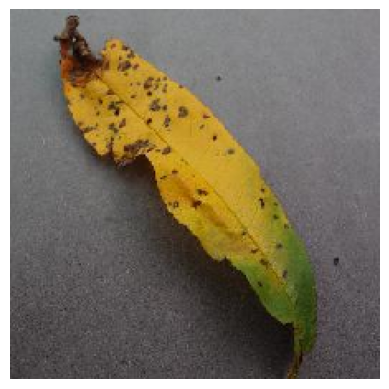

In [34]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224,224)
)

plt.imshow(img)
plt.axis("off")
plt.show()

In [35]:
img_array = tf.keras.utils.img_to_array(img)

img_array = img_array / 255.0

img_array = tf.expand_dims(img_array, 0)

In [36]:
prediction = model.predict(img_array)

predicted_class = class_names[
    tf.argmax(prediction[0])
]

confidence = tf.reduce_max(prediction[0]) * 100

print("Actual Class    :", random_class)
print("Predicted Class :", predicted_class)
print(f"Confidence      : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
Actual Class    : Peach___Bacterial_spot
Predicted Class : Peach___Bacterial_spot
Confidence      : 100.00%


In [37]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

print("Prediction Completed ✅")

Prediction Completed ✅


In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(len(class_names))),
        target_names=class_names,
        zero_division=0
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.03      0.06        33
                                 Apple___Black_rot       0.00      0.00      0.00         0
                          Apple___Cedar_apple_rust       0.00      0.00      0.00         0
                                   Apple___healthy       0.00      0.00      0.00         0
                               Blueberry___healthy       0.00      0.00      0.00         0
          Cherry_(including_sour)___Powdery_mildew       0.00      0.00      0.00         0
                 Cherry_(including_sour)___healthy       0.00      0.00      0.00         0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.00      0.00      0.00         0
                       Corn_(maize)___Common_rust_       0.00      0.00      0.00         0
               Corn_(maize)___Northern_Leaf_Blight       0.00      0.00      0.

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm.shape)

(11, 11)


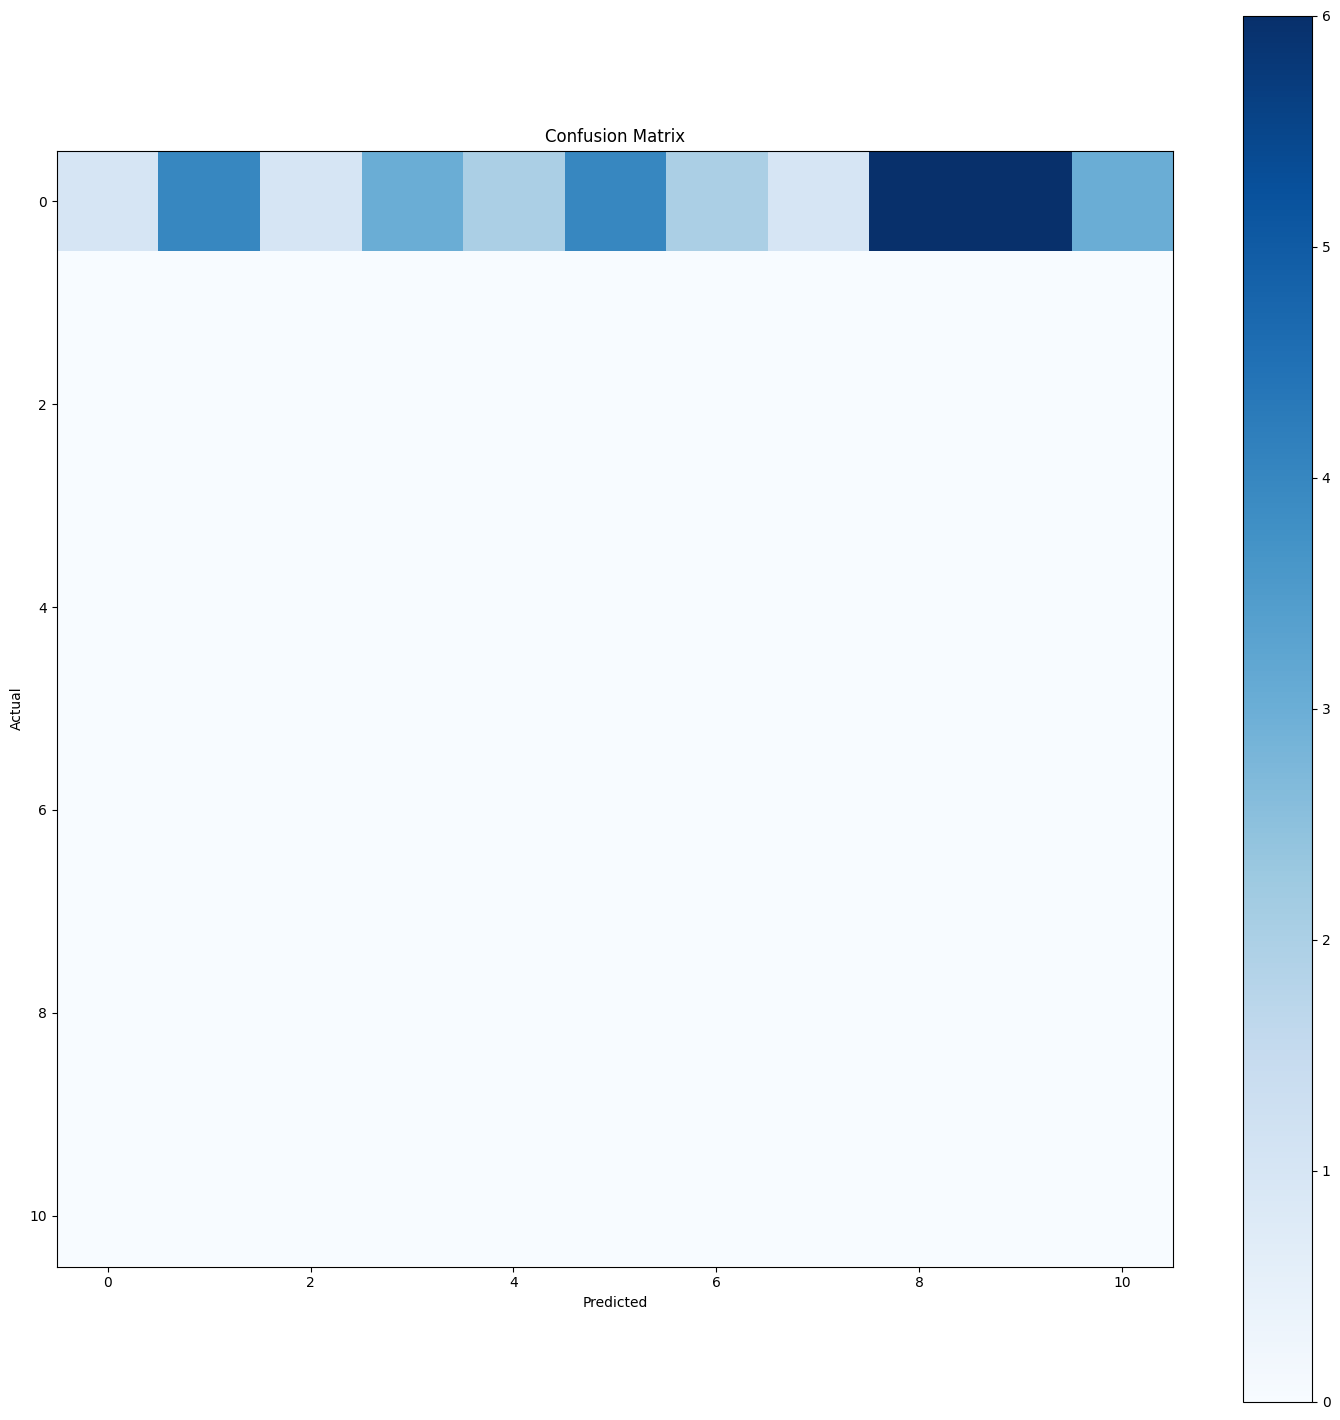

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,18))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [42]:
model.save("plant_disease_cnn.keras")

print("Model Saved Successfully ✅")

Model Saved Successfully ✅


In [43]:
from google.colab import files

files.download("plant_disease_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from tensorflow.keras import models

In [45]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print("✅ MobileNetV2 Loaded")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ MobileNetV2 Loaded


In [46]:
transfer_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        38,
        activation="softmax"
    )

])

In [47]:
transfer_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("✅ Transfer Learning Model Ready")

✅ Transfer Learning Model Ready


In [48]:
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,595,686 (9.90 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [55]:
history_transfer = transfer_model.fit(

    train_dataset,

    validation_data=valid_dataset,

    epochs=5,

    callbacks=[early_stop]

)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9714 - loss: 0.0829 - val_accuracy: 0.9813 - val_loss: 0.0562
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.9760 - loss: 0.0699 - val_accuracy: 0.9835 - val_loss: 0.0510
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 106s 48ms/step - accuracy: 0.9801 - loss: 0.0586 - val_accuracy: 0.9848 - val_loss: 0.0482
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 106s 48ms/step - accuracy: 0.9832 - loss: 0.0483 - val_accuracy: 0.9855 - val_loss: 0.0443
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 109s 50ms/step - accuracy: 0.9856 - loss: 0.0435 - val_accuracy: 0.9863 - val_loss: 0.0415


In [51]:
base_model.trainable = True

print("Total Layers:", len(base_model.layers))

Total Layers: 154


In [52]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Fine Tuning Enabled")

Fine Tuning Enabled


In [53]:
transfer_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [54]:
fine_history = transfer_model.fit(

    train_dataset,

    validation_data=valid_dataset,

    epochs=5,

    callbacks=[early_stop]

)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 144s 58ms/step - accuracy: 0.8582 - loss: 0.4647 - val_accuracy: 0.9507 - val_loss: 0.1430
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9273 - loss: 0.2183 - val_accuracy: 0.9660 - val_loss: 0.1051
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9464 - loss: 0.1590 - val_accuracy: 0.9721 - val_loss: 0.0841
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.9575 - loss: 0.1259 - val_accuracy: 0.9763 - val_loss: 0.0715
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.9672 - loss: 0.0984 - val_accuracy: 0.9793 - val_loss: 0.0617


In [63]:
mobilenet_test_loss, mobilenet_test_accuracy = transfer_model.evaluate(test_dataset)

print(f"Test Accuracy : {mobilenet_test_accuracy:.4f}")
print(f"Test Loss     : {mobilenet_test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.0909 - loss: 20.6833
Test Accuracy : 0.0909
Test Loss     : 20.6833


In [57]:
transfer_model.save("plant_disease_mobilenetv2.keras")

print("✅ MobileNetV2 Saved")

✅ MobileNetV2 Saved


In [58]:
from google.colab import files

files.download("plant_disease_mobilenetv2.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "MobileNetV2"
    ],

    "Test Accuracy": [
        cnn_test_accuracy,
        mobilenet_test_accuracy
    ],

    "Test Loss": [
        cnn_test_loss,
        mobilenet_test_loss
    ]

})

comparison

,Model,Test Accuracy,Test Loss
0,Custom CNN,0.030303,29.282763
1,MobileNetV2,0.090909,20.683277


In [65]:
import joblib

joblib.dump(class_names, "class_names.pkl")

['class_names.pkl']

In [66]:
joblib.dump(history.history, "history.pkl")

['history.pkl']

In [67]:
from google.colab import files

files.download("plant_disease_mobilenetv2.keras")
files.download("class_names.pkl")
files.download("history.pkl")
files.download("Plant_disease_detectio.ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: Plant_disease_detectio.ipynb